In [1]:
import numpy as np
import tensorflow as tf



In [2]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import pandas as pd


In [3]:
from pathlib import Path

df = pd.read_csv(Path.cwd() / 'sonar.csv', header=None)
df.head()
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21      208 non-null    float64
 22  22      208 n

In [4]:
X=df.drop(60, axis=1)
y=df[60]
X

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0203,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0051,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0155,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0042,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048


In [5]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(y)
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [6]:
X_min = X.min()
X_max = X.max()
X_max

0     0.1371
1     0.2339
2     0.3059
3     0.4264
4     0.4010
5     0.3823
6     0.3729
7     0.4590
8     0.6828
9     0.7106
10    0.7342
11    0.7060
12    0.7131
13    0.9970
14    1.0000
15    0.9988
16    1.0000
17    1.0000
18    1.0000
19    1.0000
20    1.0000
21    1.0000
22    1.0000
23    1.0000
24    1.0000
25    1.0000
26    1.0000
27    1.0000
28    1.0000
29    1.0000
30    0.9657
31    0.9306
32    1.0000
33    0.9647
34    1.0000
35    1.0000
36    0.9497
37    1.0000
38    0.9857
39    0.9297
40    0.8995
41    0.8246
42    0.7733
43    0.7762
44    0.7034
45    0.7292
46    0.5522
47    0.3339
48    0.1981
49    0.0825
50    0.1004
51    0.0709
52    0.0390
53    0.0352
54    0.0447
55    0.0394
56    0.0355
57    0.0440
58    0.0364
59    0.0439
dtype: float64

In [7]:
#train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32),
    layers.PReLU(),
    layers.Dense(16),
    layers.LeakyReLU(negative_slope=0.03),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [8]:
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train,
                    validation_data=(X_test,y_test),
                    epochs=100, 
                    batch_size=50, 
                    verbose=1,
                    validation_split=0.2
                )

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.5192 - loss: 0.7049 - val_accuracy: 0.5769 - val_loss: 0.6785
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5192 - loss: 0.7027 - val_accuracy: 0.5769 - val_loss: 0.6770
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5192 - loss: 0.7014 - val_accuracy: 0.5769 - val_loss: 0.6758
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5192 - loss: 0.6976 - val_accuracy: 0.5769 - val_loss: 0.6752
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5192 - loss: 0.6951 - val_accuracy: 0.5769 - val_loss: 0.6745
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5192 - loss: 0.6938 - val_accuracy: 0.5769 - val_loss: 0.6745
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5192 - loss: 0.6907 - val_accuracy: 0.5769 - val_loss: 0.6735
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5192 - loss: 0.6897 - val_accuracy: 0.5769 - val_loss

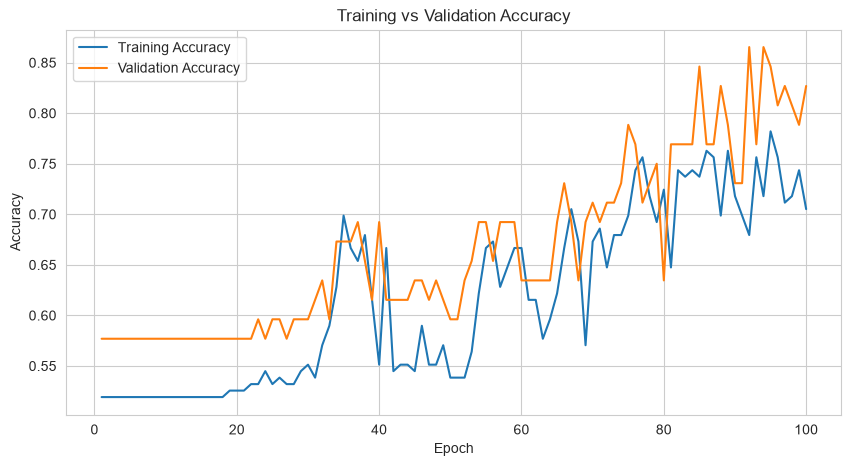

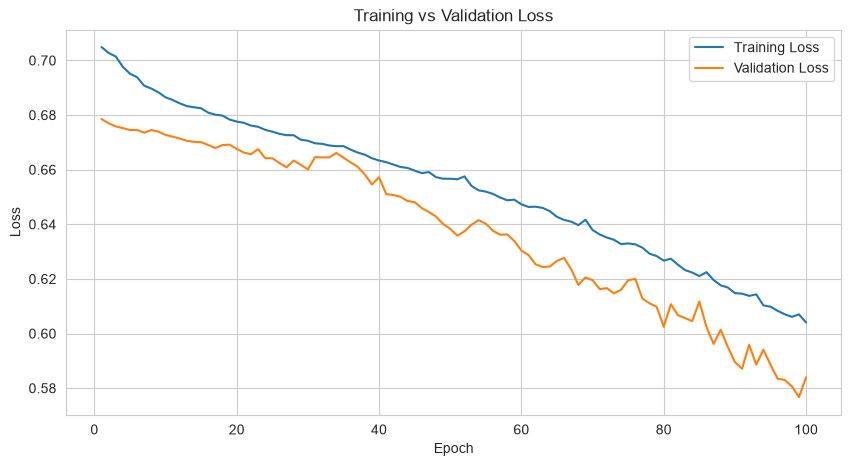

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Accuracy
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, len(history.history['accuracy'])+1),
             y=history.history['accuracy'],
             label='Training Accuracy')

sns.lineplot(x=range(1, len(history.history['val_accuracy'])+1),
             y=history.history['val_accuracy'],
             label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, len(history.history['loss'])+1),
             y=history.history['loss'],
             label='Training Loss')

sns.lineplot(x=range(1, len(history.history['val_loss'])+1),
             y=history.history['val_loss'],
             label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Stocastic Gradient Dicent using the Momentum

In [12]:
from tensorflow.keras import optimizers
opt=optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_data=(X_test,y_test),
                    epochs=100,
                    batch_size=50,
                    verbose=1,
                    validation_split=0.2
                )


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.7692 - loss: 0.6030 - val_accuracy: 0.7885 - val_loss: 0.5726
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6410 - loss: 0.6111 - val_accuracy: 0.7692 - val_loss: 0.5677
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8013 - loss: 0.5912 - val_accuracy: 0.7885 - val_loss: 0.6098
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7564 - loss: 0.6074 - val_accuracy: 0.8462 - val_loss: 0.5518
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6410 - loss: 0.5944 - val_accuracy: 0.7115 - val_loss: 0.5417
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7308 - loss: 0.5809 - val_accuracy: 0.7692 - val_loss: 0.5837
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7500 - loss: 0.5899 - val_accuracy: 0.8846 - val_loss: 0.5276
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7500 - loss: 0.5569 - val_accuracy: 0.8846 - val_loss

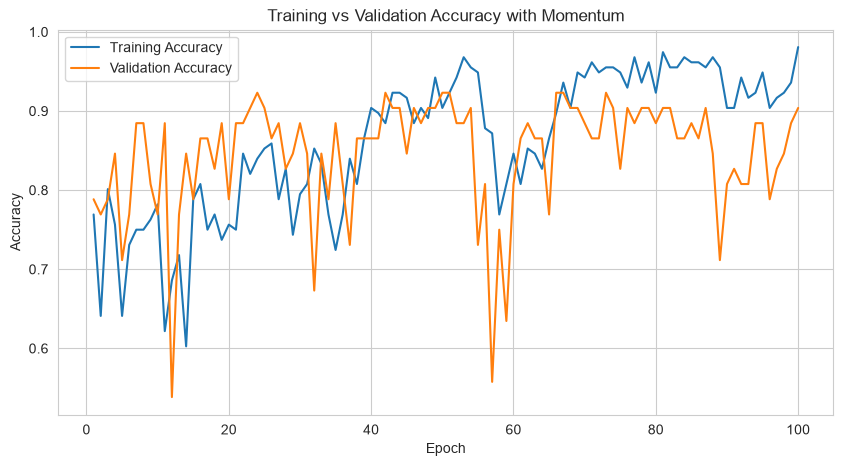

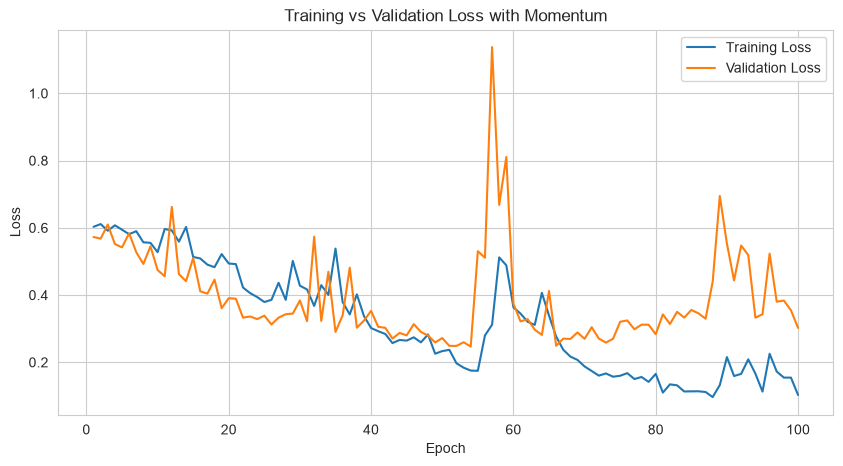

In [13]:
# Accuracy
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, len(history.history['accuracy'])+1),
             y=history.history['accuracy'],
             label='Training Accuracy')
sns.lineplot(x=range(1, len(history.history['val_accuracy'])+1),
                y=history.history['val_accuracy'],
                label='Validation Accuracy')
plt.title('Training vs Validation Accuracy with Momentum')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, len(history.history['loss'])+1),
             y=history.history['loss'],
             label='Training Loss')
sns.lineplot(x=range(1, len(history.history['val_loss'])+1),
                y=history.history['val_loss'],
                label='Validation Loss')
plt.title('Training vs Validation Loss with Momentum')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


Using Adam optimizer

In [15]:
opt2=optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt2, loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train,
                    validation_data=(X_test,y_test),
                    epochs=100, 
                    batch_size=50, 
                    verbose=1,
                    validation_split=0.2
                )


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.9679 - loss: 0.0889 - val_accuracy: 0.9038 - val_loss: 0.3671
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9808 - loss: 0.0762 - val_accuracy: 0.9038 - val_loss: 0.2921
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9872 - loss: 0.0544 - val_accuracy: 0.9038 - val_loss: 0.2834
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9872 - loss: 0.0475 - val_accuracy: 0.9038 - val_loss: 0.3132
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9936 - loss: 0.0565 - val_accuracy: 0.8846 - val_loss: 0.2960
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9936 - loss: 0.0414 - val_accuracy: 0.8846 - val_loss: 0.2915
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9872 - loss: 0.0399 - val_accuracy: 0.8846 - val_loss: 0.3011
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9936 - loss: 0.0354 - val_accuracy: 0.9038 - val_loss

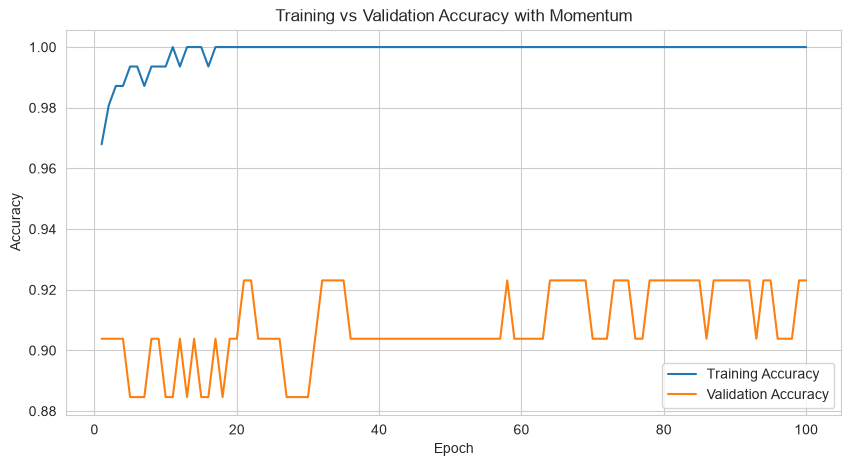

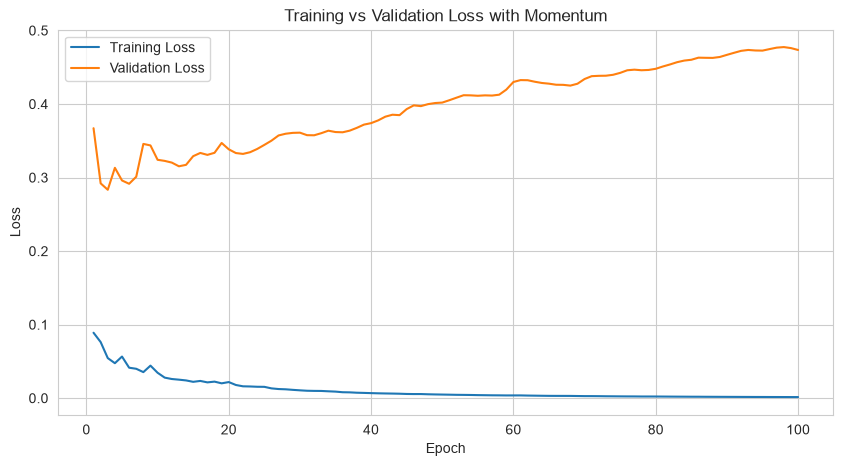

In [16]:
# Accuracy
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, len(history.history['accuracy'])+1),
             y=history.history['accuracy'],
             label='Training Accuracy')
sns.lineplot(x=range(1, len(history.history['val_accuracy'])+1),
                y=history.history['val_accuracy'],
                label='Validation Accuracy')
plt.title('Training vs Validation Accuracy with Momentum')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, len(history.history['loss'])+1),
             y=history.history['loss'],
             label='Training Loss')
sns.lineplot(x=range(1, len(history.history['val_loss'])+1),
                y=history.history['val_loss'],
                label='Validation Loss')
plt.title('Training vs Validation Loss with Momentum')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()
